In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [3]:
# Load the real GMSC dataset
gmsc = pd.read_csv(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\data\raw\GiveMeSomeCredit\cs-training.csv', index_col=0)
print(f'Dataset shape: {gmsc.shape}')
print(f'Delinquency rate: {gmsc["SeriousDlqin2yrs"].mean():.4f}')

Dataset shape: (150000, 11)
Delinquency rate: 0.0668


In [5]:
# Fill missing MonthlyIncome with median (robust to outliers)
gmsc['MonthlyIncome'] = gmsc['MonthlyIncome'].fillna(gmsc['MonthlyIncome'].median())

# Fill missing NumberOfDependents with 0 (most common value)
gmsc['NumberOfDependents'] = gmsc['NumberOfDependents'].fillna(0)

# Clip extreme values that are almost certainly data errors
gmsc['RevolvingUtilizationOfUnsecuredLines'] = gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
gmsc['DebtRatio'] = gmsc['DebtRatio'].clip(0, 10)

print('Missing values after cleaning:')
print(gmsc.isnull().sum())

Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [6]:
FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
]

FEATURE_NAMES = [
    'utilization', 'age', 'past_due_30_59', 'debt_ratio',
    'monthly_income', 'open_credit_lines', 'times_90d_late',
    'past_due_60_89', 'dependents'
]

X = gmsc[FEATURES].copy()
X.columns = FEATURE_NAMES
y = gmsc['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'Train delinquency rate: {y_train.mean():.4f}')
print(f'Test delinquency rate:  {y_test.mean():.4f}')

Training set: 120,000 rows
Test set:     30,000 rows
Train delinquency rate: 0.0668
Test delinquency rate:  0.0668


In [8]:
rf = RandomForestClassifier(
    n_estimators=200,       # 200 decision trees in the ensemble
    max_depth=12,           # Limit tree depth to prevent overfitting
    min_samples_leaf=20,    # Each leaf must have >= 20 samples
    class_weight='balanced',# Handle class imbalance automatically
    random_state=42,        # Reproducible results
    n_jobs=-1,              # Use all CPU cores
)

print('Training Random Forest (this takes ~30-60 seconds)...')
rf.fit(X_train, y_train)
print('Training complete.')

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'\nTest AUC-ROC: {auc:.4f}')
print('Expected: ~0.78-0.82')

Training Random Forest (this takes ~30-60 seconds)...
Training complete.

Test AUC-ROC: 0.8664
Expected: ~0.78-0.82


In [9]:
y_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {auc:.4f}')           # Target: ~0.79

pos_scores = y_proba[y_test==1]
neg_scores = y_proba[y_test==0]
ks_stat, _ = stats.ks_2samp(pos_scores, neg_scores)
print(f'KS Statistic: {ks_stat:.4f}')  # Target: ~0.44

sorted_idx    = y_proba.argsort()[::-1]
top10_cutoff  = int(len(y_proba) * 0.10)
top10_actual  = y_test.values[sorted_idx[:top10_cutoff]]
prec_top10    = top10_actual.mean()
print(f'Precision@Top10%: {prec_top10:.4f}')  # Target: ~0.25 (3.7x lift)')

AUC-ROC: 0.8664
KS Statistic: 0.5745
Precision@Top10%: 0.3650


In [10]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
# Expected: ~0.79 ± 0.005 — low variance confirms a stable model

5-Fold CV AUC: 0.8590 ± 0.0044


In [14]:
import numpy as np
print(f"Type: {type(shap_values)}")
print(f"Shape: {np.array(shap_values).shape if isinstance(shap_values, list) else shap_values.shape}")
print(f"X_sample shape: {X_sample.shape}")

Type: <class 'numpy.ndarray'>
Shape: (500, 9, 2)
X_sample shape: (500, 9)


SHAP values shape: (500, 9)
X_sample shape:    (500, 9)


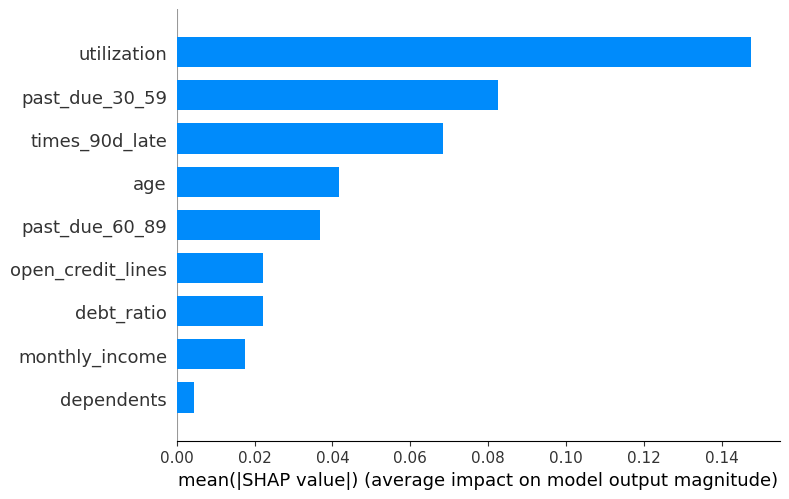

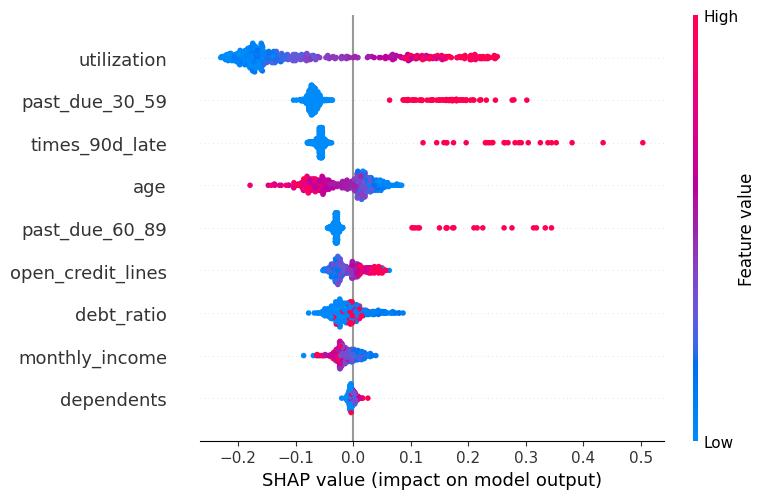

In [16]:
import shap
import numpy as np

explainer   = shap.TreeExplainer(rf)
X_sample    = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Handle both old (list) and new (3D array) SHAP return formats
if isinstance(shap_values, list):
    # Old SHAP: list of arrays, one per class
    shap_class1 = shap_values[1]
else:
    # New SHAP: single 3D array, last dim is class
    shap_class1 = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_class1.shape}")
print(f"X_sample shape:    {X_sample.shape}")
# Both should be (500, 9)

# Bar plot — mean absolute SHAP across all customers
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_class1, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Dot plot — shows direction and magnitude of feature impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_class1, X_sample, show=False)
plt.tight_layout()
plt.savefig(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
joblib.dump(rf,            r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\models/risk_rf_model.pkl')
joblib.dump(FEATURE_NAMES, r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\models/feature_names.pkl')
joblib.dump(explainer,     r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\models/shap_explainer.pkl')

for f in Path(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\models').iterdir():
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name}: {size_kb:.1f} KB')

  .gitkeep: 0.0 KB
  feature_names.pkl: 0.1 KB
  risk_rf_model.pkl: 20170.1 KB
  shap_explainer.pkl: 28621.6 KB
